# Ayush Desai
## MLP Ghost Listing Classifier - NYC Airbnb

**Goal:** Train a binary MLP to predict whether a listing is a ghost listing.

**Ghost label definition** (from R preprocessing in fit_models.r):
- availability_365 > 300 AND (reviews_per_month is missing OR reviews_per_month < 0.1)
- OR reviews_per_month == 0 AND calculated_host_listings_count > 3

**Input:** ghost_data.csv produced by prepare_data.R

**Output:** mlp_ghost_predictions.csv with columns id, ghost_prob_mlp, ghost_pred

In [6]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [ ]:
import os
from pathlib import Path

# Ensure the working directory is models/ regardless of where Jupyter was launched.
# All relative paths in this notebook (../data/, ../frontend/) are anchored to models/.
for candidate in [Path('.'), Path('models')]:
    if (candidate / 'MLP_ghost_classifier.ipynb').exists():
        os.chdir(candidate)
        break

print('Working directory:', os.getcwd())

In [7]:
# ── Manual replacements for sklearn ──────────────────────────────────────────

def train_test_split(X, y, test_size=0.2, random_state=None, stratify=None):
    rng = np.random.RandomState(random_state)
    if stratify is not None:
        classes = np.unique(stratify)
        train_idx, test_idx = [], []
        for c in classes:
            c_idx = rng.permutation(np.where(stratify == c)[0])
            n_test = max(1, round(len(c_idx) * test_size))
            test_idx.append(c_idx[:n_test])
            train_idx.append(c_idx[n_test:])
        train_idx = rng.permutation(np.concatenate(train_idx))
        test_idx  = rng.permutation(np.concatenate(test_idx))
    else:
        idx    = rng.permutation(len(y))
        n_test = max(1, round(len(y) * test_size))
        test_idx, train_idx = idx[:n_test], idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


class ManualStandardScaler:
    def __init__(self):
        self.mean_  = None
        self.scale_ = None

    def fit_transform(self, X):
        self.mean_  = X.mean(axis=0)
        self.scale_ = X.std(axis=0, ddof=0)          # population std (same as sklearn)
        self.scale_[self.scale_ == 0] = 1.0           # avoid divide-by-zero for const cols
        return (X - self.mean_) / self.scale_

    def transform(self, X):
        return (X - self.mean_) / self.scale_

def confusion_matrix(y_true, y_pred):
    TP = int(((y_true == 1) & (y_pred == 1)).sum())
    TN = int(((y_true == 0) & (y_pred == 0)).sum())
    FP = int(((y_true == 0) & (y_pred == 1)).sum())
    FN = int(((y_true == 1) & (y_pred == 0)).sum())
    return np.array([[TN, FP], [FN, TP]])

def accuracy_score(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def precision_score(y_true, y_pred, zero_division=0):
    TP = int(((y_true == 1) & (y_pred == 1)).sum())
    FP = int(((y_true == 0) & (y_pred == 1)).sum())
    denom = TP + FP
    return TP / denom if denom > 0 else float(zero_division)

def recall_score(y_true, y_pred, zero_division=0):
    TP = int(((y_true == 1) & (y_pred == 1)).sum())
    FN = int(((y_true == 1) & (y_pred == 0)).sum())
    denom = TP + FN
    return TP / denom if denom > 0 else float(zero_division)

def f1_score(y_true, y_pred, zero_division=0):
    p = precision_score(y_true, y_pred, zero_division=zero_division)
    r = recall_score(y_true, y_pred, zero_division=zero_division)
    denom = p + r
    return 2 * p * r / denom if denom > 0 else float(zero_division)

def roc_curve(y_true, y_score):
    thresholds = np.sort(np.unique(y_score))[::-1]   # descending
    n_pos = int(y_true.sum())
    n_neg = len(y_true) - n_pos
    fprs, tprs = [], []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fp = int(((y_pred == 1) & (y_true == 0)).sum())
        tprs.append(tp / n_pos)
        fprs.append(fp / n_neg)
    # Add boundary points so the curve spans [0,0] → [1,1]
    fprs = np.array([0.0] + fprs + [1.0])
    tprs = np.array([0.0] + tprs + [1.0])
    thresh_out = np.concatenate([[thresholds[0] + 1e-10], thresholds, [thresholds[-1] - 1e-10]])
    return fprs, tprs, thresh_out

def roc_auc_score(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    order = np.argsort(fpr)
    return float(np.trapz(tpr[order], fpr[order]))

def precision_recall_curve(y_true, y_score):
    thresholds = np.sort(np.unique(y_score))[::-1]   # descending
    n_pos = int(y_true.sum())
    precs, recs = [], []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tp = int(((y_pred == 1) & (y_true == 1)).sum())
        fp = int(((y_pred == 1) & (y_true == 0)).sum())
        fn = int(((y_pred == 0) & (y_true == 1)).sum())
        precs.append(tp / (tp + fp) if (tp + fp) > 0 else 0.0)
        recs.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
    # Sentinel: precision=1, recall=0 (matches sklearn)
    return np.array(precs + [1.0]), np.array(recs + [0.0]), thresholds

In [8]:
# Load airbnb_clean.csv and engineer all features needed by the MLP.
# This replicates the R prepare_data pipeline in Python.

df = pd.read_csv('../data/airbnb_clean.csv', low_memory=False)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

# ── Parse numeric price (stored as "$87.00") ──────────────────────────────────
df['price_num'] = (df['price']
                   .astype(str)
                   .str.replace(r'[$,]', '', regex=True)
                   .pipe(pd.to_numeric, errors='coerce'))

# ── Ghost label ───────────────────────────────────────────────────────────────
# availability_365 > 300 AND (reviews_per_month is NA OR reviews_per_month < 0.1)
# OR reviews_per_month == 0 AND calculated_host_listings_count > 3
rpm  = pd.to_numeric(df['reviews_per_month'], errors='coerce')
chlc = pd.to_numeric(df['calculated_host_listings_count'], errors='coerce')
avail = pd.to_numeric(df['availability_365'], errors='coerce')

cond1 = (avail > 300) & (rpm.isna() | (rpm < 0.1))
cond2 = (rpm == 0)    & (chlc > 3)
df['ghost'] = (cond1 | cond2).astype(int)

# ── Engineered features ───────────────────────────────────────────────────────
df['borough']        = df['neighbourhood_group_cleansed']
# log of host listing count (clip to 1 to avoid log(0))
df['log_host_count'] = np.log(chlc.clip(lower=1))
# log(1 + reviews) — NA reviews treated as 0
df['log_reviews']    = np.log1p(pd.to_numeric(df['number_of_reviews'], errors='coerce').fillna(0))
# review completeness: overall rating score (NA = no reviews → imputed 0 later as ghost signal)
df['review_complete'] = pd.to_numeric(df['review_scores_rating'], errors='coerce')
# price relative to borough median (positive ratio, suitable for log1p)
borough_med = df.groupby('borough')['price_num'].transform('median')
df['price_vs_neigh'] = df['price_num'] / borough_med.replace(0, np.nan)

# ── Drop rows missing any core modeling column ────────────────────────────────
df = df.dropna(subset=['accommodates', 'log_host_count', 'price_vs_neigh',
                        'borough', 'room_type']).reset_index(drop=True)

y = df['ghost'].astype(int).values
n_pos, n_neg = y.sum(), (y == 0).sum()
print(f'\nGhost listings (1): {n_pos:,} ({n_pos/len(y)*100:.1f}%)')
print(f'Normal listings (0): {n_neg:,} ({n_neg/len(y)*100:.1f}%)')
print(f'Imbalance ratio: {n_neg/n_pos:.1f}x')

Loaded: 36,353 rows x 72 columns

Ghost listings (1): 4,717 (22.0%)
Normal listings (0): 16,698 (78.0%)
Imbalance ratio: 3.5x


In [9]:
# Continuous features - log-transform skewed raw columns before scaling
cont_cols = ['accommodates', 'log_host_count', 'price_vs_neigh',
             'review_complete', 'log_reviews']

for col in cont_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# review_complete NA means no reviews - ghost signal, so impute at 0
df['review_complete'] = df['review_complete'].fillna(0.0)
df['price_vs_neigh']  = df['price_vs_neigh'].fillna(df['price_vs_neigh'].median())

# Log-transform skewed continuous features that aren't already logged
for col in ['accommodates', 'price_vs_neigh']:
    df[col] = np.log1p(df[col].clip(lower=0))

# One-hot encode borough and room_type
borough_dummies = pd.get_dummies(df['borough'],   prefix='borough').astype(float)
room_dummies    = pd.get_dummies(df['room_type'], prefix='room').astype(float)

X_df = pd.concat(
    [df[cont_cols].reset_index(drop=True),
     borough_dummies.reset_index(drop=True),
     room_dummies.reset_index(drop=True)],
    axis=1
).fillna(0).astype(float)

print(f'Feature matrix: {X_df.shape[0]:,} rows x {X_df.shape[1]} columns')
print(f'Features: {list(X_df.columns)}')

Feature matrix: 21,415 rows x 14 columns
Features: ['accommodates', 'log_host_count', 'price_vs_neigh', 'review_complete', 'log_reviews', 'borough_Bronx', 'borough_Brooklyn', 'borough_Manhattan', 'borough_Queens', 'borough_Staten Island', 'room_Entire home/apt', 'room_Hotel room', 'room_Private room', 'room_Shared room']


In [10]:
# 70/15/15 train/val/test
X_arr = X_df.values
n_cont = len(cont_cols)  

X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_arr, y, test_size=0.15, random_state=42, stratify=y
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp
)

# Scale continuous columns only (leave one-hot encoded columns as-is)
scaler = ManualStandardScaler()

def scale_features(X, fit=False):
    X = X.copy()
    if fit:
        X[:, :n_cont] = scaler.fit_transform(X[:, :n_cont])
    else:
        X[:, :n_cont] = scaler.transform(X[:, :n_cont])
    return X

x_train = scale_features(X_train_raw, fit=True)
x_val   = scale_features(X_val_raw)
x_test  = scale_features(X_test_raw)

d = x_train.shape[1]
print(f'Train: {len(y_train):,} (ghost: {y_train.sum():,})')
print(f'Val: {len(y_val):,} (ghost: {y_val.sum():,})')
print(f'Test: {len(y_test):,} (ghost: {y_test.sum():,})')
print(f'Input features: {d}')

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Positive class weight: {pos_weight:.2f}')

Train: 14,990 (ghost: 3,302)
Val: 3,212 (ghost: 707)
Test: 3,213 (ghost: 708)
Input features: 14
Positive class weight: 3.54


In [11]:
# Helper functions

def sigmoid(z):
    return np.where(z >= 0,
                    1.0 / (1.0 + np.exp(-z)),
                    np.exp(z) / (1.0 + np.exp(z)))

def relu(z):
    return np.maximum(0, z)

def dropout_mask(shape, p_drop, training=True):
    if not training or p_drop == 0:
        return np.ones(shape)
    # boolean mask (True where rand > p_drop), divided by (1-p_drop) to keep expected activation magnitude constant
    mask = (np.random.rand(*shape) > p_drop) / (1.0 - p_drop)
    return mask

def forward(X, W1, b1, W2, b2, W3, b3, W4, b4,
            p_drop=0.0, training=False):
    # Hidden layers: ReLU + inverted dropout; output: sigmoid
    Z1 = X @ W1 + b1                              # (n, 128)
    H1 = relu(Z1) * dropout_mask(Z1.shape, p_drop, training)
    Z2 = H1 @ W2 + b2                             # (n, 64)
    H2 = relu(Z2) * dropout_mask(Z2.shape, p_drop, training)
    Z3 = H2 @ W3 + b3                             # (n, 32)
    H3 = relu(Z3) * dropout_mask(Z3.shape, p_drop, training)
    Z4 = H3 @ W4 + b4                             # (n, 1)
    return sigmoid(Z4), H1, H2, H3, Z1, Z2, Z3

In [12]:
# Architecture: d -> 128 -> 64 -> 32 -> 1
# Mini-batch SGD + cosine LR decay + dropout + early stopping

np.random.seed(42)

n        = x_train.shape[0]
eta_max  = 0.001          # peak learning rate
eta_min  = 1e-5           # floor for cosine decay
epochs   = 300
batch_sz = 256
p_drop   = 0.3            # dropout probability per hidden layer
patience = 35             # early stopping - generous for imbalanced val loss

# He initialization
W1 = np.random.randn(d,   128) * math.sqrt(2.0 / d)
b1 = np.zeros(128)
W2 = np.random.randn(128,  64) * math.sqrt(2.0 / 128)
b2 = np.zeros(64)
W3 = np.random.randn(64,   32) * math.sqrt(2.0 / 64)
b3 = np.zeros(32)
W4 = np.random.randn(32,    1) * math.sqrt(2.0 / 32)
b4 = np.zeros(1)

tr_losses, vl_losses = [], []
best_val, best_params = float('inf'), None
wait = 0

w_val = np.where(y_val == 1, pos_weight, 1.0).reshape(-1, 1)
y_vl  = y_val.reshape(-1, 1).astype(float)

n_batches = math.ceil(n / batch_sz)

for epoch in range(epochs):

    # Cosine LR schedule
    eta = eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * epoch / epochs))

    # Shuffle training data each epoch
    idx = np.random.permutation(n)
    x_shuf, y_shuf = x_train[idx], y_train[idx]

    epoch_loss = 0.0

    for b in range(n_batches):
        xb = x_shuf[b*batch_sz : (b+1)*batch_sz]
        yb = y_shuf[b*batch_sz : (b+1)*batch_sz].reshape(-1, 1).astype(float)
        wb = np.where(yb == 1, pos_weight, 1.0)
        nb = len(yb)

        # Forward (training mode - dropout active)
        Y, H1, H2, H3, Z1, Z2, Z3 = forward(
            xb, W1, b1, W2, b2, W3, b3, W4, b4, p_drop=p_drop, training=True
        )

        p = np.clip(Y, 1e-9, 1 - 1e-9)
        batch_loss = float(np.mean(wb * (-yb * np.log(p) - (1 - yb) * np.log(1 - p))))
        epoch_loss += batch_loss

        # Backprop
        dZ4 = wb * (Y - yb) / nb
        dW4 = H3.T @ dZ4;  db4 = dZ4.sum(axis=0)

        dH3 = dZ4 @ W4.T
        dZ3 = dH3 * (Z3 > 0)
        dW3 = H2.T @ dZ3;  db3 = dZ3.sum(axis=0)

        dH2 = dZ3 @ W3.T
        dZ2 = dH2 * (Z2 > 0)
        dW2 = H1.T @ dZ2;  db2 = dZ2.sum(axis=0)

        dH1 = dZ2 @ W2.T
        dZ1 = dH1 * (Z1 > 0)
        dW1 = xb.T @ dZ1;  db1 = dZ1.sum(axis=0)

        W4 -= eta * dW4;  b4 -= eta * db4
        W3 -= eta * dW3;  b3 -= eta * db3
        W2 -= eta * dW2;  b2 -= eta * db2
        W1 -= eta * dW1;  b1 -= eta * db1

    tr_losses.append(epoch_loss / n_batches)

    # Validation (inference mode - no dropout)
    Y_val, *_ = forward(x_val, W1, b1, W2, b2, W3, b3, W4, b4, p_drop=0.0, training=False)
    pv = np.clip(Y_val, 1e-9, 1 - 1e-9)
    vl_loss = float(np.mean(w_val * (-y_vl * np.log(pv) - (1 - y_vl) * np.log(1 - pv))))
    vl_losses.append(vl_loss)

    # Early stopping
    if vl_loss < best_val:
        best_val = vl_loss
        best_params = (W1.copy(), b1.copy(), W2.copy(), b2.copy(),
                       W3.copy(), b3.copy(), W4.copy(), b4.copy())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f'  Early stop at epoch {epoch+1}  (best val loss={best_val:.4f})')
            break

    if (epoch + 1) % 50 == 0:
        print(f'  Epoch {epoch+1:>4}  lr={eta:.6f}  train loss={tr_losses[-1]:.4f}  val loss={vl_losses[-1]:.4f}')

# Restore best weights
W1, b1, W2, b2, W3, b3, W4, b4 = best_params
print('Done.')

  Epoch   50  lr=0.000936  train loss=0.7534  val loss=0.6505
  Epoch  100  lr=0.000757  train loss=0.7080  val loss=0.6401
  Epoch  150  lr=0.000510  train loss=0.6998  val loss=0.6344
  Epoch  200  lr=0.000262  train loss=0.6997  val loss=0.6319
  Epoch  250  lr=0.000079  train loss=0.6901  val loss=0.6308
  Epoch  300  lr=0.000010  train loss=0.6835  val loss=0.6306
Done.


In [13]:
# Tune classification threshold on val set using F1

Y_val_prob, *_ = forward(x_val, W1, b1, W2, b2, W3, b3, W4, b4, p_drop=0.0, training=False)
y_prob_val = Y_val_prob.squeeze()

prec_v, rec_v, thresh_v = precision_recall_curve(y_val, y_prob_val)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)
best_thresh = float(thresh_v[f1_v[:-1].argmax()])

print(f'Best threshold (val F1): {best_thresh:.4f}')
print(f'Val F1 at threshold:     {f1_v[:-1].max():.4f}')

Best threshold (val F1): 0.7474
Val F1 at threshold:     0.6667


In [14]:
# Evaluate on test set using tuned threshold
# Accuracy alone is misleading with imbalanced data — focus on F1 and AUC

Y_test, *_ = forward(x_test, W1, b1, W2, b2, W3, b3, W4, b4, p_drop=0.0, training=False)
y_prob_test = Y_test.squeeze()
y_pred_test = (y_prob_test >= best_thresh).astype(int)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)
auc  = roc_auc_score(y_test, y_prob_test)
cm   = confusion_matrix(y_test, y_pred_test)

print(f'Threshold used: {best_thresh:.4f}')
print(f'Test Accuracy: {acc:.4f}')
print(f'Test Precision: {prec:.4f}')
print(f'Test Recall: {rec:.4f}')
print(f'Test F1: {f1:.4f}')
print(f'Test ROC-AUC: {auc:.4f}')
print(f'\nConfusion Matrix:')
print(f'TN={cm[0,0]:,} FP={cm[0,1]:,}')
print(f'FN={cm[1,0]:,} TP={cm[1,1]:,}')

Threshold used: 0.7474
Test Accuracy: 0.8251
Test Precision: 0.5811
Test Recall: 0.7387
Test F1: 0.6505
Test ROC-AUC: 0.8755

Confusion Matrix:
  TN=2,128 FP=377
  FN=185 TP=523


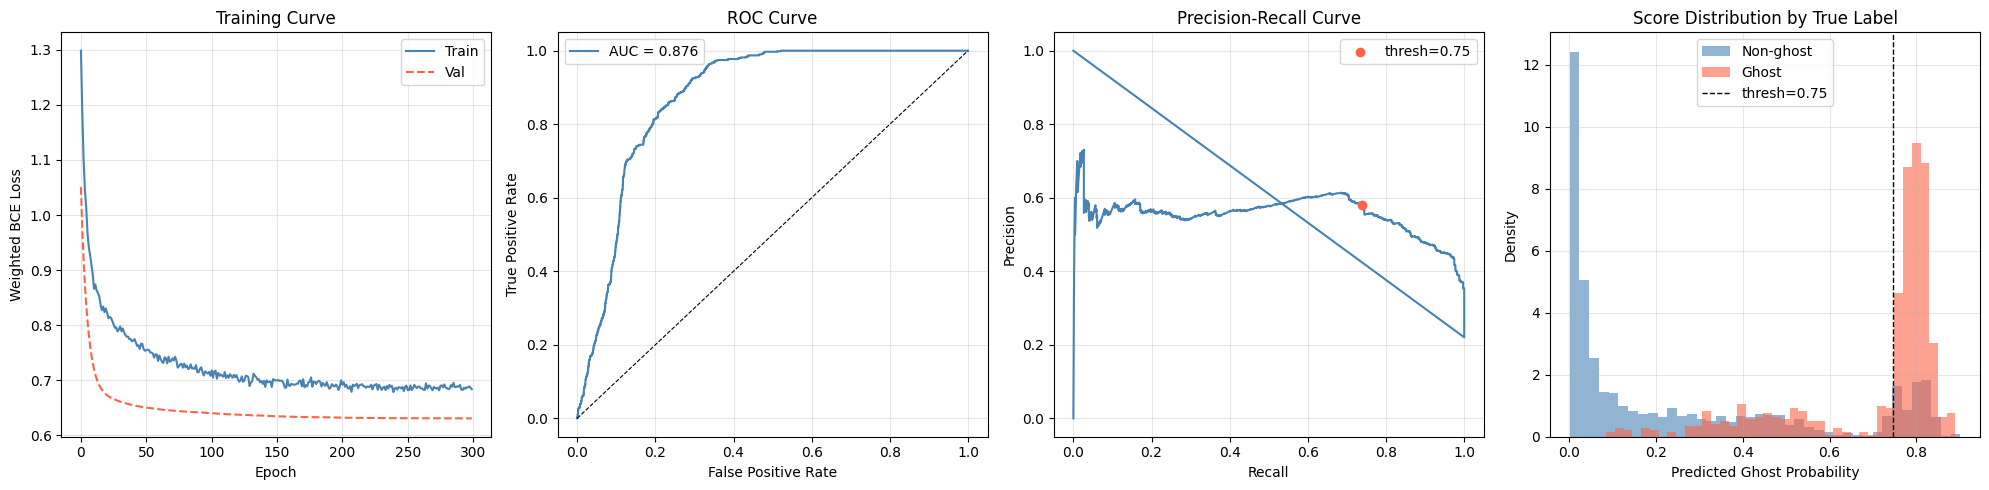

Saved ../frontend/www/mlp_diagnostics.png


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Training curve
ax = axes[0]
ax.plot(tr_losses, label='Train', color='steelblue')
ax.plot(vl_losses, label='Val',   color='tomato', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Weighted BCE Loss')
ax.set_title('Training Curve'); ax.legend(); ax.grid(alpha=0.3)

# ROC curve
# Receiver Operating Characteristic visualizes performance across all classification thresholds.
# It plots the True Positive Rate (Sensitivity) on the y-axis against the False Positive Rate on the x-axis.
# AUC summarizes overall performance: 1.0 = perfect, 0.5 = random guessing.

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
ax = axes[1]
ax.plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.3f}')
ax.plot([0,1],[0,1],'k--',linewidth=0.8)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve'); ax.legend(); ax.grid(alpha=0.3)

# Precision-Recall Curve — especially informative on imbalanced data
# where ghost listings (1) are far less common than normal listings (0).

prec_t, rec_t, thresh_t = precision_recall_curve(y_test, y_prob_test)
ax = axes[2]
ax.plot(rec_t, prec_t, color='steelblue')
idx_t = np.argmin(np.abs(thresh_t - best_thresh))
ax.scatter(rec_t[idx_t], prec_t[idx_t], color='tomato', zorder=5,
           label=f'thresh={best_thresh:.2f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve'); ax.legend(); ax.grid(alpha=0.3)

# Score distribution by true label
ax = axes[3]
ax.hist(y_prob_test[y_test==0], bins=40, alpha=0.6, color='steelblue', label='Non-ghost', density=True)
ax.hist(y_prob_test[y_test==1], bins=40, alpha=0.6, color='tomato',    label='Ghost',     density=True)
ax.axvline(best_thresh, color='black', linestyle='--', linewidth=1, label=f'thresh={best_thresh:.2f}')
ax.set_xlabel('Predicted Ghost Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by True Label')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../frontend/www/mlp_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ../frontend/www/mlp_diagnostics.png')

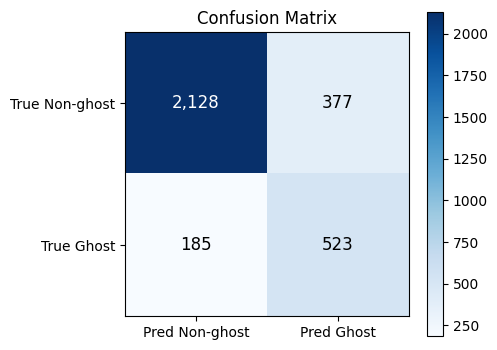

Saved ../frontend/www/mlp_confusion_matrix.png


In [20]:
# Confusion matrix plot
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Non-ghost', 'Pred Ghost'])
ax.set_yticklabels(['True Non-ghost', 'True Ghost'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
ax.set_title(f'Confusion Matrix')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('../frontend/www/mlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ../frontend/www/mlp_confusion_matrix.png')

In [17]:
# Scale full dataset using already-fitted scaler 

X_all = scale_features(X_arr)
Y_all, *_ = forward(X_all, W1, b1, W2, b2, W3, b3, W4, b4, p_drop=0.0, training=False)
y_prob_all = Y_all.squeeze()
y_pred_all = (y_prob_all >= best_thresh).astype(int)

print(f'All listings: {len(y_prob_all):,}')
print(f'Predicted ghost (prob >= {best_thresh:.3f}): {y_pred_all.sum():,} ({y_pred_all.mean()*100:.1f}%)')
print(f'True ghost label count: {y.sum():,} ({y.mean()*100:.1f}%)')

All listings: 21,415
Predicted ghost (prob >= 0.747): 6,037 (28.2%)
True ghost label count: 4,717 (22.0%)


In [18]:
# Save the trained model weights and decision threshold, and the scaling parameters
# needed to normalize new data the same way as training data
np.savez('mlp_weights.npz',
         W1=W1, b1=b1, W2=W2, b2=b2,
         W3=W3, b3=b3, W4=W4, b4=b4,
         threshold=np.array([best_thresh]))

np.savez('scaler_params.npz',
         mean=scaler.mean_,
         scale=scaler.scale_,
         n_cont=np.array([n_cont]))

print('Saved mlp_weights.npz and scaler_params.npz')

Saved mlp_weights.npz and scaler_params.npz


In [19]:
# Build results table and save to data/ so the Shiny app can access it

out = pd.DataFrame({
    'id':             df['id'].values,
    'ghost_prob_mlp': y_prob_all,
    'ghost_pred':     y_pred_all,
})
out.to_csv('../data/mlp_ghost_predictions.csv', index=False)
print('Saved ../data/mlp_ghost_predictions.csv')
print(f'Rows: {len(out):,}')
out.head(10)

Saved ../data/mlp_ghost_predictions.csv
Rows: 21,415


,id,ghost_prob_mlp,ghost_pred
0,1274691077561855573,0.036607,0
1,1274722590671904755,0.367083,0
2,1274773188072371454,0.806753,1
3,1274820999428562667,0.815067,1
4,1274826163511555978,0.429865,0
5,1274909412180886814,0.204026,0
6,1274943629134607784,0.351990,0
7,1275276318052624457,0.239042,0
8,1279691717688251905,0.815731,1
9,1279699245295400653,0.813171,1
